In [1]:
# Import necessary packages
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
import numpy as np
import os
import sys
from numpyro.infer import MCMC, NUTS
from numpyro.infer import init_to_value, init_to_median


# Add project to path
sys.path.append("..")

# Import project modules
from src.data import load_data
from src.model import SectionedModel
from src.mcmc import (
    numpyro_model_isotropic,
    numpyro_model_radial_tangential
)
from src.comparison import compute_savage_dickey_ratio, plot_savage_dickey_ratio
from src.visualisation import plot_sectioned_model

# Set plot style
plt.style.use('mystyle.mplstyle')

# Path to the data file
data_file = '../data/1-Fragment_C_Hole_Measurements.csv'

# Set up numpyro for parallelism
numpyro.set_platform("cpu")
numpyro.set_host_device_count(8)  # Adjust based on your CPU cores
rng_key = jax.random.PRNGKey(0)

/Users/clementine/mphildis/coursework/S2/xl628/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
jax.local_device_count()

1

#  1. Isotropic Model

## 1.1 Fit

In [3]:
# Load data and initialize model
data = load_data(data_file)
model_isotropic = SectionedModel(data)
n_sections = model_isotropic.n_sections

prior_config_isotropic = {
    "N_min": 300, "N_max": 400,
    "r_min": 65, "r_max": 85,
    "sigma_min": 1e-5, "sigma_max": 1,
    "x0_min": 70.0, "x0_max": 90.0,
    "y0_min": 120.0, "y0_max": 150.0,
    "alpha_min": 1.1*jnp.pi, "alpha_max": 1.3*jnp.pi
}

nuts_sampler_isotropic = NUTS(
    numpyro_model_isotropic
)

mcmc_isotropic = MCMC(
    nuts_sampler_isotropic, 
    num_warmup=2000, 
    num_samples=8000, 
    num_chains=8,
    thinning=2
)


mcmc_isotropic.run(
    rng_key, 
    model=model_isotropic, 
    data=data, 
    prior_config=prior_config_isotropic
)
mcmc_isotropic.print_summary() 

/var/folders/gs/q6cb20s96xl8zvw1zgbf79hc0000gn/T/ipykernel_47057/3795479773.py:19: UserWarning: There are not enough devices to run parallel chains: expected 8 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(8)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_isotropic = MCMC(
sample: 100%|██████████| 10000/10000 [01:49<00:00, 91.68it/s, 255 steps of size 1.95e-02. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    359.25      1.03    359.24    357.53    360.91  27762.97      1.00
   alpha_1      3.74      0.01      3.74      3.73      3.76  29120.85      1.00
   alpha_2      3.75      0.03      3.75      3.69      3.80  28868.82      1.00
   alpha_3      3.75      0.00      3.75      3.75      3.76  30031.16      1.00
   alpha_5      3.75      0.08      3.75      3.63      3.87  24097.22      1.00
   alpha_6      3.77      0.08      3.77      3.64      3.89  22994.41      1.00
   alpha_7      3.73      0.05      3.72      3.63      3.81  27407.04      1.00
         r     77.45      0.20     77.45     77.12     77.79  29565.42      1.00
     sigma      0.34      0.02      0.34      0.31      0.37  27216.02      1.00
      x0_1     79.76      0.49     79.76     78.95     80.55  29514.59      1.00
      x0_2     79.94      2.19     79.96     76.43     83.60  28710.04      1.00
      x0_3     79.88      0

In [4]:


def save_mcmc_results(mcmc, output_file, param_names=None, save_all_samples=True):
    samples = mcmc.get_samples()
    if param_names is None:
        param_names = list(samples.keys())

    sample_arrays = []
    for param in param_names:
        if param in samples:
            param_samples = samples[param]
            if len(param_samples.shape) > 1:
                for i in range(param_samples.shape[1]):
                    sample_arrays.append(param_samples[:, i])
                    if param_names is not None and f"{param}_{i}" not in param_names:
                        param_names.append(f"{param}_{i}")
            else:
                sample_arrays.append(param_samples)
    
    all_samples = np.column_stack(sample_arrays)
    
    means = np.mean(all_samples, axis=0)
    stds = np.std(all_samples, axis=0)
    medians = np.median(all_samples, axis=0)
    
    ci_68_lower = np.percentile(all_samples, 16, axis=0)  # 68% CI
    ci_68_upper = np.percentile(all_samples, 84, axis=0)
    ci_90_lower = np.percentile(all_samples, 5, axis=0)   # 90% CI
    ci_90_upper = np.percentile(all_samples, 95, axis=0)
    ci_95_lower = np.percentile(all_samples, 2.5, axis=0) # 95% CI
    ci_95_upper = np.percentile(all_samples, 97.5, axis=0)
    ci_99_lower = np.percentile(all_samples, 0.5, axis=0) # 99% CI
    ci_99_upper = np.percentile(all_samples, 99.5, axis=0)
    
    results_dict = {
        "Parameter": param_names,
        "Mean": means,
        "Median": medians,
        "Std": stds,
        "68%_lower": ci_68_lower,
        "68%_upper": ci_68_upper,
        "90%_lower": ci_90_lower,
        "90%_upper": ci_90_upper,
        "95%_lower": ci_95_lower,
        "95%_upper": ci_95_upper,
        "99%_lower": ci_99_lower,
        "99%_upper": ci_99_upper
    }
    
    results_df = pd.DataFrame(results_dict)
    results_df.to_csv(output_file, index=False)
    
    if save_all_samples:
        samples_file = f"{output_file.rsplit('.', 1)[0]}_samples.csv"
        samples_df = pd.DataFrame(all_samples, columns=param_names)
        samples_df.to_csv(samples_file, index=False)
    
    return results_df

save_mcmc_results(mcmc_isotropic, "results/mcmc_isotropic.csv", save_all_samples=True)

,Parameter,Mean,Median,Std,68%_lower,68%_upper,90%_lower,90%_upper,95%_lower,95%_upper,99%_lower,99%_upper
0,N,359.252472,359.244598,1.033696,358.231964,360.271240,357.567963,360.953094,357.234009,361.283112,356.575806,361.963837
1,alpha_1,3.742478,3.742545,0.008359,3.734153,3.750774,3.728685,3.756201,3.726047,3.758838,3.720603,3.763893
2,alpha_2,3.746030,3.746172,0.032123,3.714230,3.777857,3.693447,3.798670,3.683119,3.808731,3.662287,3.829330
3,alpha_3,3.752832,3.752849,0.004585,3.748307,3.757371,3.745270,3.760336,3.743703,3.761833,3.740836,3.764789
4,alpha_5,3.754486,3.752503,0.075356,3.667479,3.842162,3.637800,3.876441,3.630437,3.884585,3.622442,3.892956
5,alpha_6,3.765981,3.765126,0.078637,3.674318,3.858412,3.643785,3.890018,3.636565,3.897375,3.628935,3.906084
6,alpha_7,3.727027,3.723368,0.053394,3.671082,3.782412,3.645090,3.821035,3.636647,3.839052,3.627172,3.872588
7,r,77.448936,77.449547,0.203485,77.247063,77.650894,77.118637,77.782875,77.049652,77.848824,76.914230,77.977249
8,sigma,0.339243,0.338181,0.020066,0.319320,0.359247,0.308166,0.374135,0.303009,0.381433,0.293310,0.396146
9,x0_1,79.764320,79.763733,0.487213,79.280640,80.247444,78.963081,80.565788,78.809998,80.720528,78.512833,81.008202


### 1.2 Corner Plot

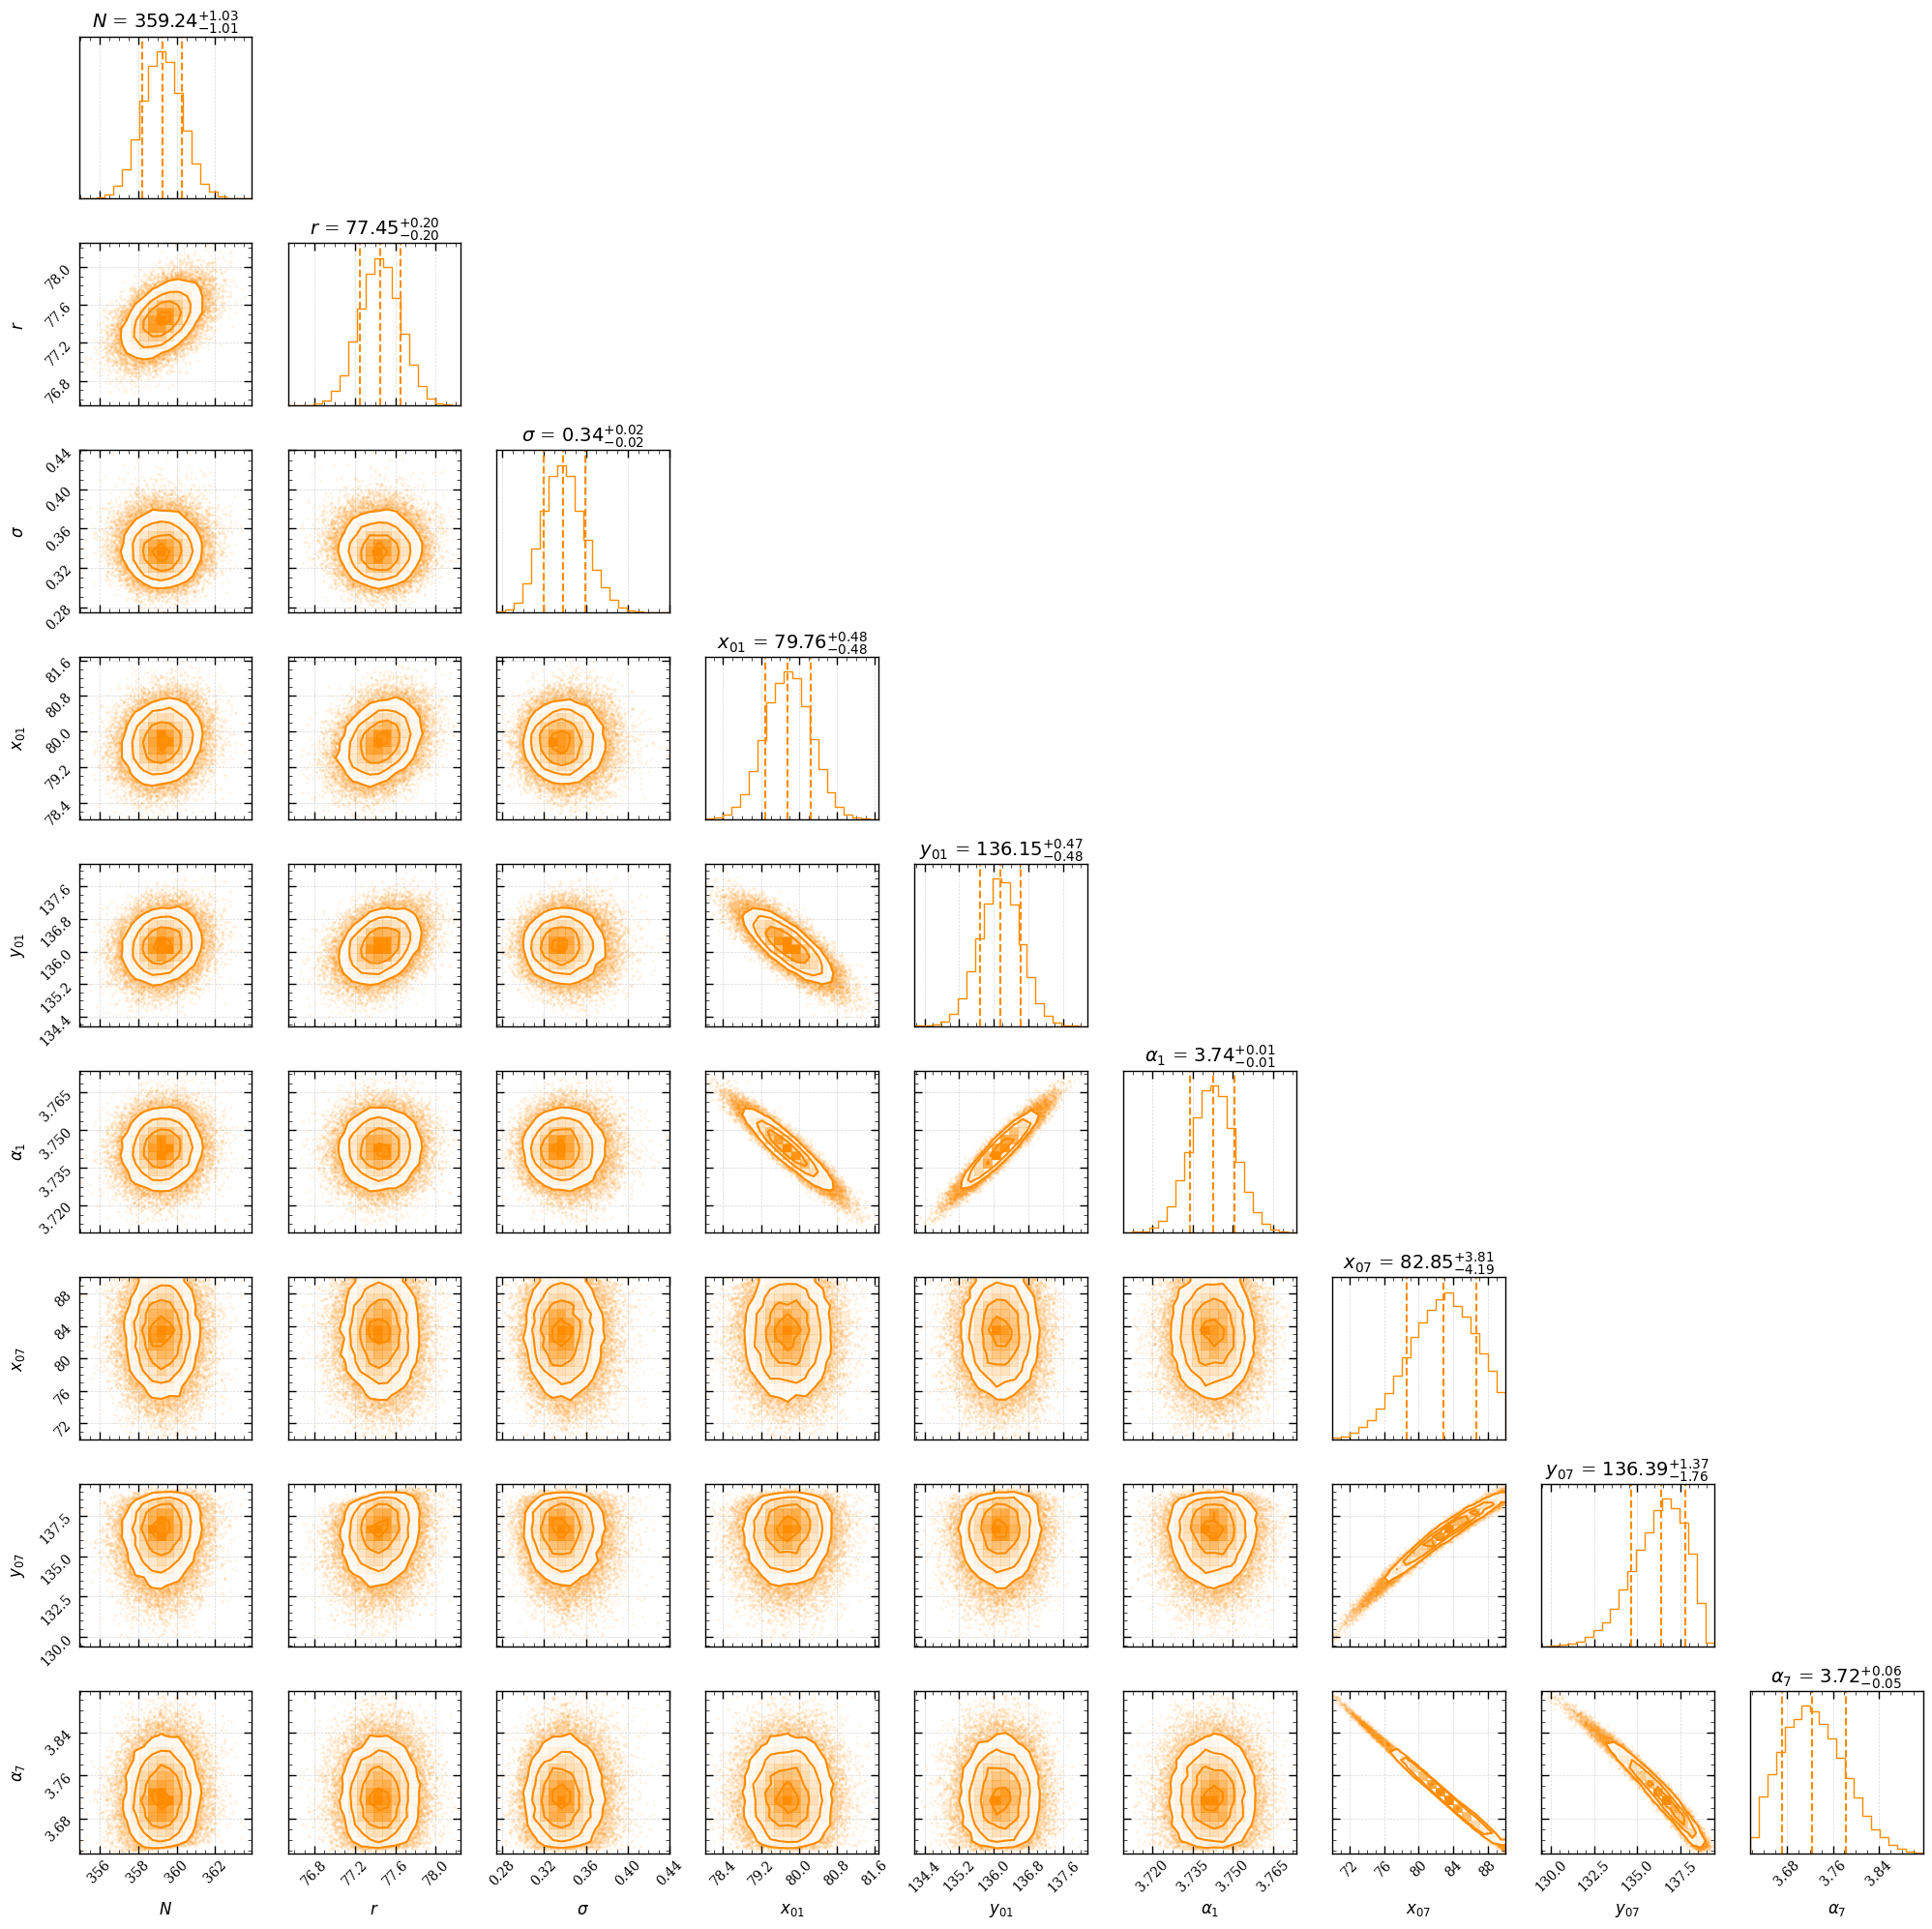

In [5]:
import corner
import numpy as np

samples = mcmc_isotropic.get_samples()
param_names = ["N", "r", "sigma", "x0_1", "y0_1", "alpha_1", "x0_7", "y0_7", "alpha_7"]
tex_param_names = ["$N$", "$r$", "$\sigma$", "$x_{01}$", "$y_{01}$", r"$\alpha_{1}$", "$x_{07}$", "$y_{07}$", r"$\alpha_{7}$"]
param_samples = np.vstack([samples[name] for name in param_names]).T

corner_kwargs = {
    "labels": tex_param_names,
    "quantiles": [0.16, 0.5, 0.84],
    "show_titles": True,
    "color": "darkorange",
}

figure = corner.corner(param_samples, **corner_kwargs)
plt.tight_layout()
plt.savefig('figures/corner_plot_isotropic.pdf')
plt.show()

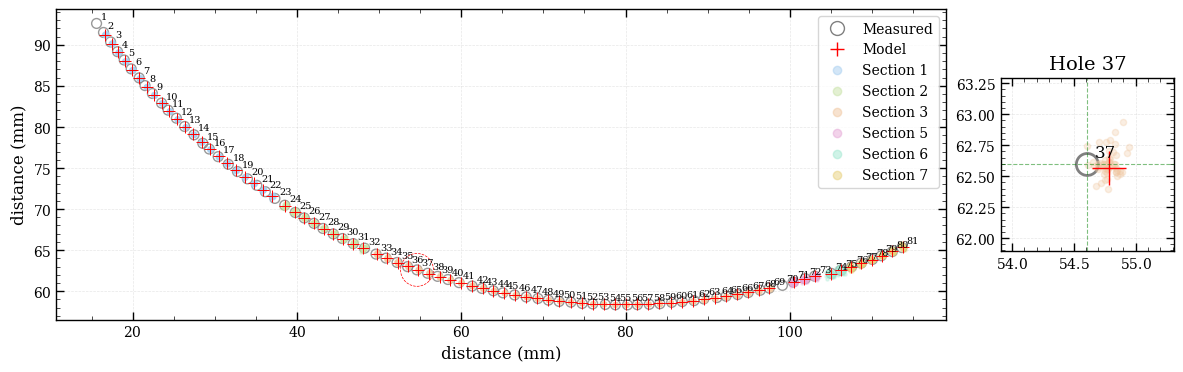

In [14]:
import importlib
import src.visualisation
importlib.reload(src.visualisation)
median_dict_isotropic = {k: jnp.median(v, axis=0) for k, v in mcmc_isotropic.get_samples().items()}
fig = src.visualisation.plot_sectioned_model(
    data=data,
    model=model_isotropic,
    params=median_dict_isotropic, 
    posterior_samples=mcmc_isotropic.get_samples(),
    n_post_samples=50,
    highlight_hole=37,
    excluded_sections=[0, 4]
)
fig.savefig('figures/isotropic_model.pdf')

In [7]:
import numpy as np
corr_matrix = np.corrcoef([samples[f"alpha_{i}"] for i in [1, 2, 3, 5, 6, 7]])
print(corr_matrix)

[[ 1.          0.00853725  0.02593947  0.00431575  0.02189378  0.00429488]
 [ 0.00853725  1.          0.01756819 -0.00265479  0.00432121  0.00604315]
 [ 0.02593947  0.01756819  1.          0.02508989  0.01697801  0.03153521]
 [ 0.00431575 -0.00265479  0.02508989  1.          0.00571818  0.00739336]
 [ 0.02189378  0.00432121  0.01697801  0.00571818  1.          0.00367165]
 [ 0.00429488  0.00604315  0.03153521  0.00739336  0.00367165  1.        ]]


In [8]:
from numpyro.infer.util import log_likelihood
samples = mcmc_isotropic.get_samples()
log_like = log_likelihood(numpyro_model_isotropic, samples, model_isotropic, data)
print(log_like)

{'obs_1': Array([[-33064.473,  -9366.685],
       [-29453.807,  -8387.271],
       [-31653.688,  -8985.091],
       ...,
       [-33305.11 ,  -9462.193],
       [-34148.176,  -9607.979],
       [-32597.246,  -9201.41 ]], dtype=float32), 'obs_10': Array([[0.13006848, 0.17586917],
       [0.08283567, 0.12888487],
       [0.16136847, 0.13179377],
       ...,
       [0.1987949 , 0.19856219],
       [0.15513325, 0.17845224],
       [0.18165462, 0.16344458]], dtype=float32), 'obs_11': Array([[-0.08007793,  0.175419  ],
       [-0.13931705,  0.11642297],
       [ 0.14046706, -0.02296406],
       ...,
       [ 0.11553422,  0.13102895],
       [ 0.20701148,  0.20662257],
       [ 0.02926482,  0.03573991]], dtype=float32), 'obs_12': Array([[ 0.04315002,  0.17816672],
       [-0.05320297,  0.12582931],
       [ 0.16757312,  0.01450428],
       ...,
       [ 0.16941825,  0.1527392 ],
       [ 0.2093966 ,  0.21076116],
       [ 0.08888312,  0.07570005]], dtype=float32), 'obs_13': Array([[ 0.1083547

## 2. Radial/Tangential Model

### 2.1 Fit

In [16]:
model_radial_tangential = SectionedModel(data)

prior_config_radial_tangential = {
    "N_min": 300, "N_max": 400,
    "r_min": 65, "r_max": 85,
    "sigma_r_min": 1e-5, "sigma_r_max": 1,
    "sigma_t_min": 1e-5, "sigma_t_max": 1,
    "x0_min": 70.0, "x0_max": 90.0,
    "y0_min": 120.0, "y0_max": 150.0,
    "alpha_min": 1.1*jnp.pi, "alpha_max": 1.3*jnp.pi
}
nuts_sampler_radial_tangential = NUTS(numpyro_model_radial_tangential)

mcmc_radial_tangential = MCMC(
    nuts_sampler_radial_tangential, 
    num_warmup=2000, 
    num_samples=8000, 
    num_chains=8,
    thinning=2
)

mcmc_radial_tangential.run(
    rng_key=rng_key, 
    model=model_radial_tangential, 
    data=data, 
    prior_config=prior_config_radial_tangential
)
mcmc_radial_tangential.print_summary()

/var/folders/gs/q6cb20s96xl8zvw1zgbf79hc0000gn/T/ipykernel_47057/2958423369.py:14: UserWarning: There are not enough devices to run parallel chains: expected 8 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(8)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_radial_tangential = MCMC(
sample: 100%|██████████| 10000/10000 [24:27<00:00,  6.82it/s, 255 steps of size 1.43e-02. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         N    358.52      1.23    358.51    356.55    360.58  28097.12      1.00
   alpha_1      3.74      0.00      3.74      3.74      3.74  28137.90      1.00
   alpha_2      3.75      0.00      3.75      3.74      3.75  28438.25      1.00
   alpha_3      3.75      0.00      3.75      3.75      3.76  28074.08      1.00
   alpha_5      3.73      0.02      3.73      3.70      3.77  26891.58      1.00
   alpha_6      3.74      0.05      3.74      3.66      3.82  27976.28      1.00
   alpha_7      3.72      0.01      3.72      3.70      3.73  28248.09      1.00
         r     76.87      0.03     76.87     76.82     76.92  30320.14      1.00
   sigma_r      0.04      0.00      0.04      0.03      0.05  25759.84      1.00
   sigma_t      0.49      0.04      0.49      0.42      0.55  26560.50      1.00
      x0_1     79.36      0.06     79.36     79.27     79.46  30012.99      1.00
      x0_2     79.69      0

In [17]:
save_mcmc_results(mcmc_radial_tangential, "results/mcmc_radial_tangential.csv", save_all_samples=True)

,Parameter,Mean,Median,Std,68%_lower,68%_upper,90%_lower,90%_upper,95%_lower,95%_upper,99%_lower,99%_upper
0,N,358.521393,358.507355,1.228024,357.318359,359.727356,356.533478,360.565308,356.127838,360.978455,355.379211,361.813904
1,alpha_1,3.741872,3.741744,0.001771,3.740018,3.743491,3.738842,3.744656,3.738253,3.745233,3.737140,3.746377
2,alpha_2,3.745096,3.745170,0.004648,3.740498,3.749691,3.737399,3.752711,3.735872,3.754118,3.733153,3.757043
3,alpha_3,3.751096,3.751088,0.003196,3.747977,3.754285,3.745897,3.756425,3.744895,3.757447,3.742839,3.759509
4,alpha_5,3.734087,3.734283,0.021864,3.712427,3.755573,3.697918,3.769946,3.691135,3.777257,3.676477,3.790078
5,alpha_6,3.742094,3.741657,0.045751,3.695487,3.787906,3.667141,3.818817,3.654504,3.834240,3.637131,3.864661
6,alpha_7,3.716051,3.716077,0.009034,3.707103,3.724913,3.701119,3.730927,3.698112,3.733857,3.692566,3.739508
7,r,76.870163,76.870316,0.028754,76.841820,76.898643,76.823486,76.917557,76.814186,76.927101,76.795982,76.946739
8,sigma_r,0.040375,0.040133,0.003547,0.036877,0.043884,0.034950,0.046578,0.034144,0.047991,0.032642,0.050903
9,sigma_t,0.488604,0.485589,0.040982,0.448640,0.528712,0.426460,0.560994,0.417253,0.578204,0.398148,0.612985


### 2.2 Savage Dickey Ratio

Posterior density at sigma_r = sigma_t: 0.0
Prior density at sigma_r = sigma_t: 0.08685889638065036
Bayes factor in favor of the isotropic model: 0.0000


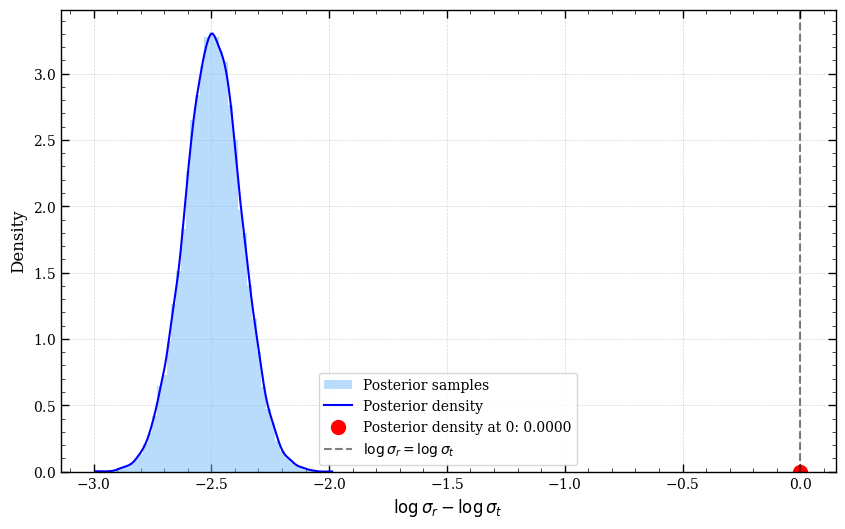

In [ ]:
import src.comparison
importlib.reload(src.comparison)
mcmc_samples = mcmc_radial_tangential.get_samples()

bayes_factor = src.comparison.compute_savage_dickey_ratio(mcmc_samples, prior_config_radial_tangential)
fig = src.comparison.plot_savage_dickey_ratio(mcmc_samples)
plt.savefig('figures/savage_dickey_ratio.pdf')
print(f"Bayes factor in favor of the isotropic model: {bayes_factor:.4f}")

### 2.3 Visualisation

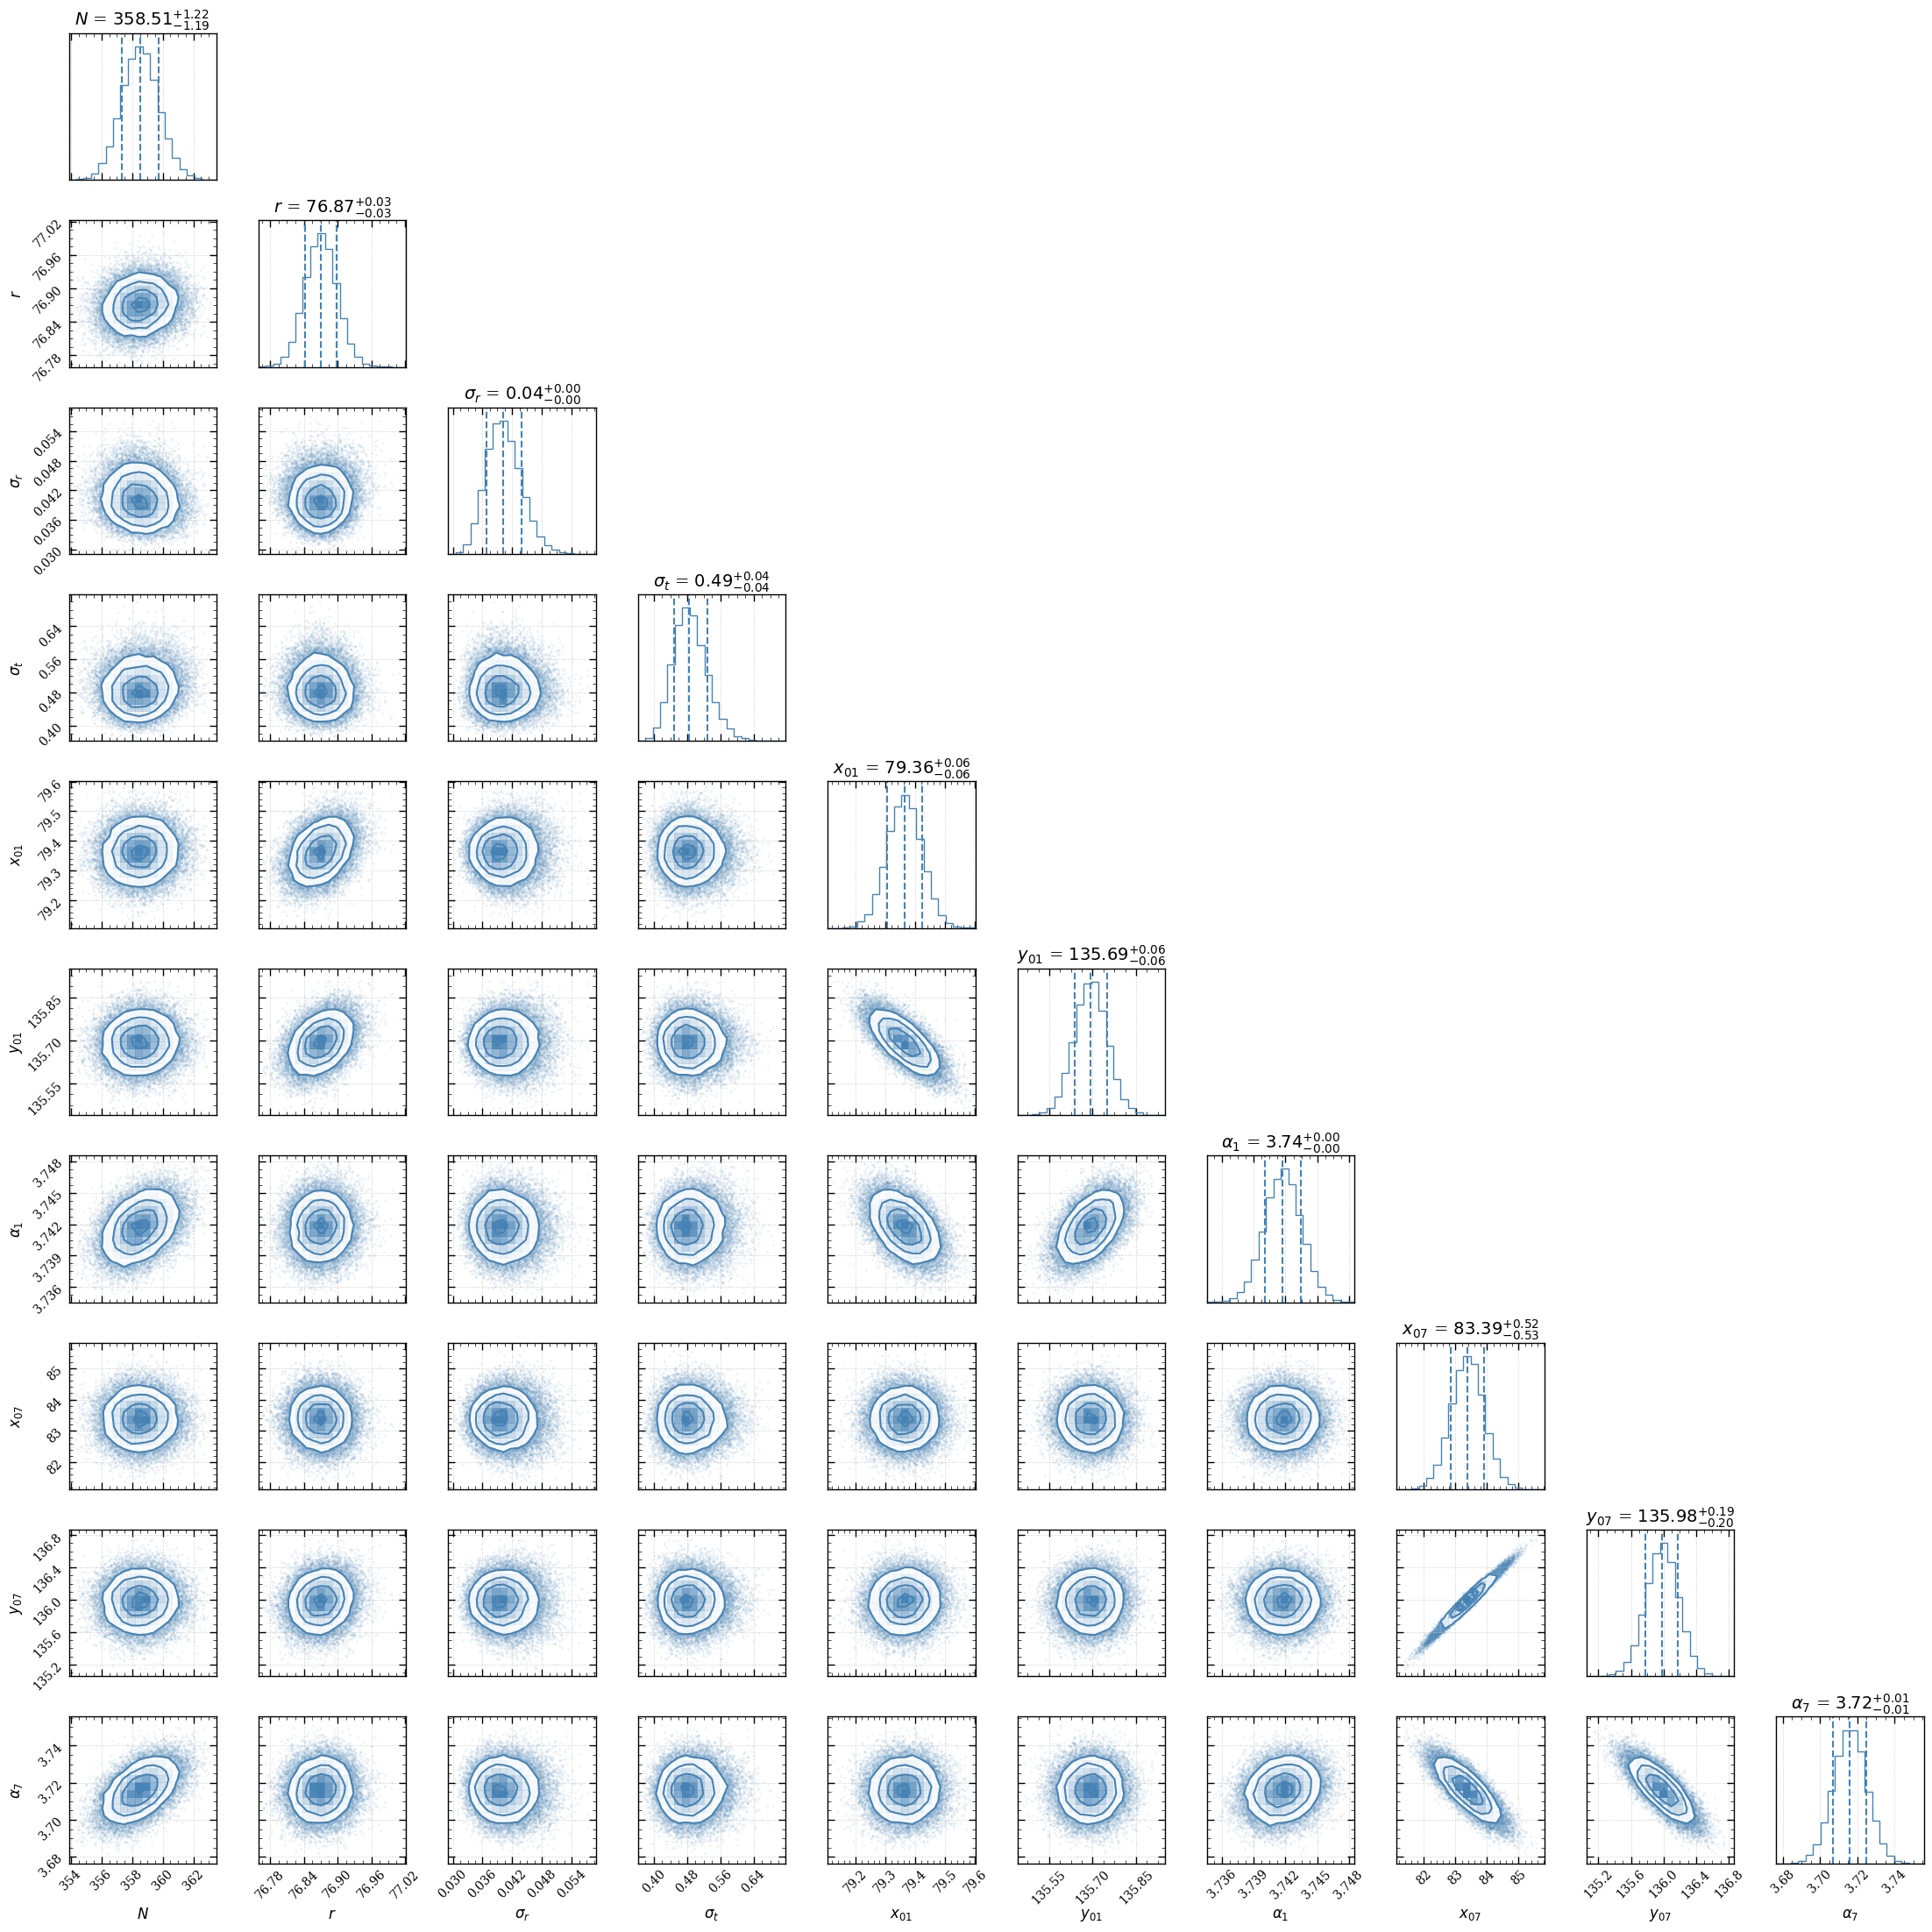

In [22]:
samples = mcmc_radial_tangential.get_samples()
param_names = ["N", "r", "sigma_r", "sigma_t", "x0_1", "y0_1", "alpha_1", "x0_7", "y0_7", "alpha_7"]
tex_param_names = ["$N$", "$r$", "$\sigma_r$", "$\sigma_t$", "$x_{01}$", "$y_{01}$", r"$\alpha_{1}$", "$x_{07}$", "$y_{07}$", r"$\alpha_{7}$"]
param_samples = np.vstack([samples[name] for name in param_names]).T

corner_kwargs = {
    "labels": tex_param_names,
    "quantiles": [0.16, 0.5, 0.84],
    "show_titles": True,
    "color": "steelblue",
}

figure = corner.corner(param_samples, **corner_kwargs)
plt.tight_layout()
plt.savefig('figures/corner_plot_radial_tangential.pdf')
plt.show()

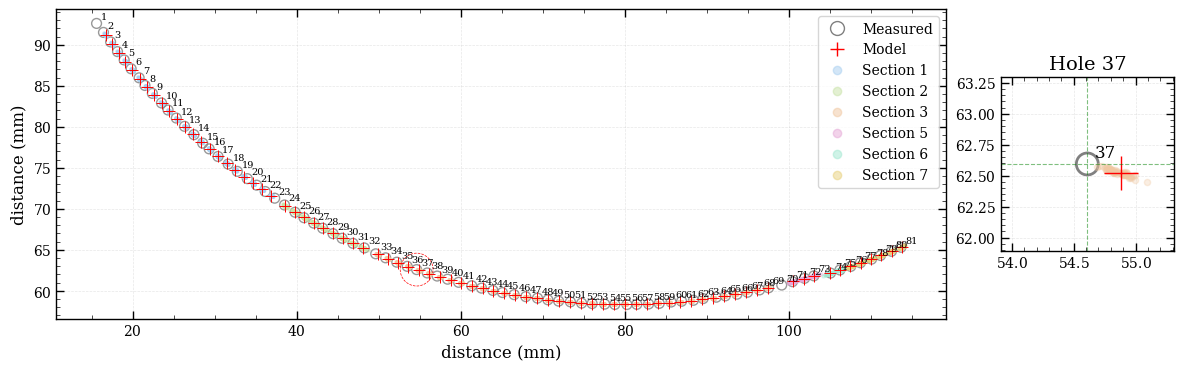

In [20]:
median_dict_radial_tangential = {k: jnp.median(v, axis=0) for k, v in mcmc_samples.items()}
fig = src.visualisation.plot_sectioned_model(
    data=data,
    model=model_radial_tangential,
    params=median_dict_radial_tangential, 
    posterior_samples=mcmc_samples,
    n_post_samples=50,
    highlight_hole=37,
    excluded_sections=[0, 4]
)
fig.savefig('figures/radial_tangential_model.pdf')